In [59]:
#Importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report,roc_auc_score,roc_curve)
np.random.seed(42)

In [12]:
#Load the dataset
df = pd.read_csv("diabetes_prediction_dataset_2000.csv")
df.head(5)

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,13.0,0,0,No Info,20.82,5.8,126,0
1,Female,3.0,0,0,No Info,21.00,5.0,145,0
2,Male,63.0,0,0,former,25.32,3.5,200,0
3,Female,2.0,0,0,never,17.43,6.1,126,0
4,Female,33.0,0,0,not current,40.08,6.2,200,1


In [15]:
#Basic dataset checking
print("Dataset shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Dataset shape: (1996, 9)

Columns:
['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes']

Data types:
gender                  object
age                    float64
hypertension             int64
heart_disease            int64
smoking_history         object
bmi                    float64
HbA1c_level            float64
blood_glucose_level      int64
diabetes                 int64
dtype: object

Missing values:
gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

Duplicate rows: 0


In [16]:
#Removing duplicates
df = df.drop_duplicates()
print("Shape After Removing duplicates:", df.shape)

Shape After Removing duplicates: (1996, 9)


In [76]:
#Checking diabetes classes
print("Diabetes counts:")
print(df["diabetes"].value_counts())
print("\nPercentage of each class:")
print((df["diabetes"].value_counts(normalize=True) * 100).round(2))

Diabetes counts:
diabetes
0    1831
1     165
Name: count, dtype: int64

Percentage of each class:
diabetes
0    91.73
1     8.27
Name: proportion, dtype: float64


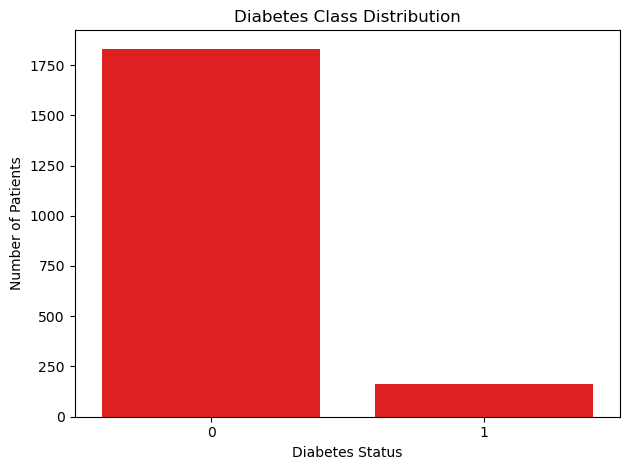

In [18]:
#Diabetes class visualizationsplt.figure(figsize=(6, 4))

sns.countplot(data=df,x="diabetes",color='red')
plt.title("Diabetes Class Distribution")
plt.xlabel("Diabetes Status")
plt.ylabel("Number of Patients")
plt.tight_layout()
plt.show()

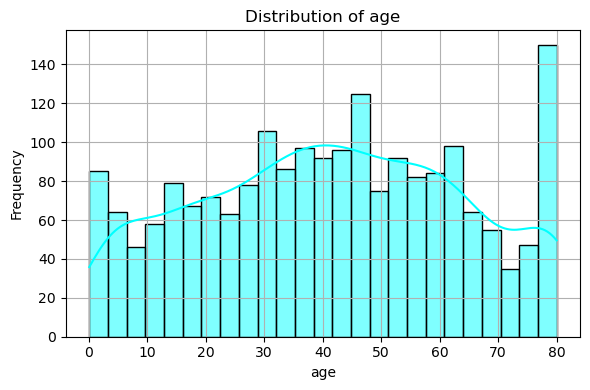

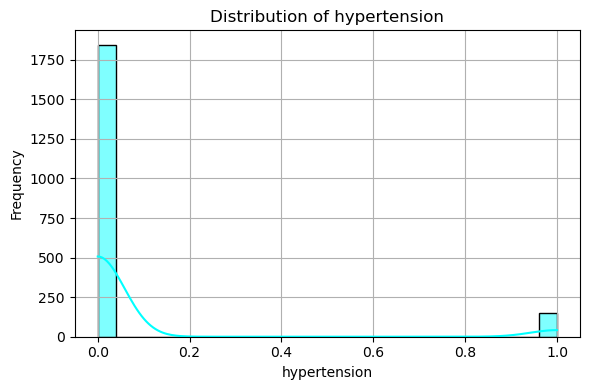

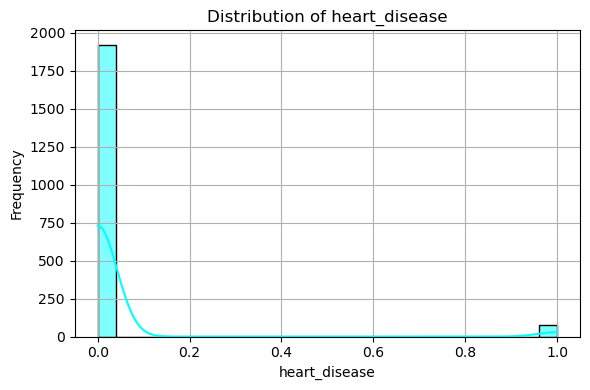

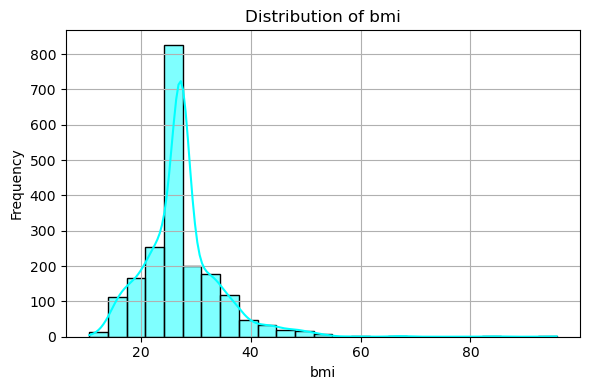

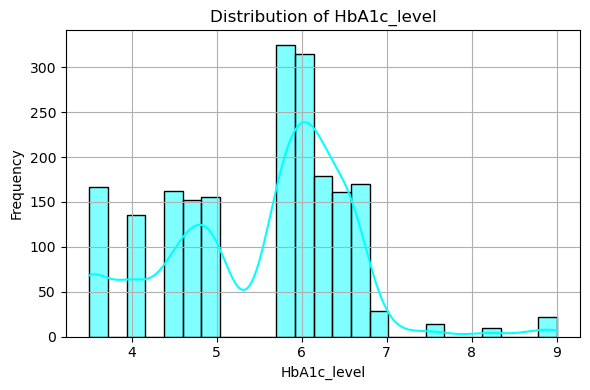

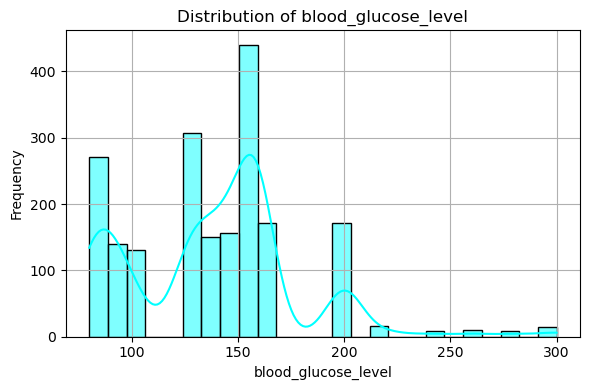

In [85]:
#Distribution of numerical variables
num_cols = ["age","hypertension","heart_disease","bmi","HbA1c_level","blood_glucose_level"]
#checking for each column
for col in num_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col], bins=25,kde=True,color='aqua')
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.grid()
    plt.tight_layout()
    plt.show()

In [ ]:
#Distribution of categorical variables(gender,smoking histruy)
cat_cols = ["gender","smoking_history"]

for col in cat_cols:
    plt.figure(figsize=(7, 4))
    sns.countplot(data=df,x=col,color='violet')
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

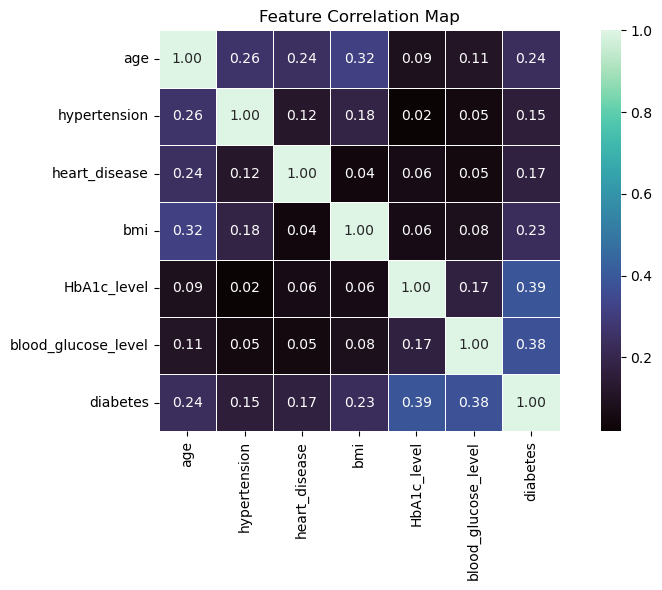

In [20]:
#Correlation heatmapp
corr = df[num_cols + ["diabetes"]].corr()
plt.figure(figsize=(9, 6))
sns.heatmap(corr,annot=True,fmt=".2f",cmap="mako",linewidths=0.6,square=True)
plt.title("Feature Correlation Map")
plt.tight_layout()
plt.show()

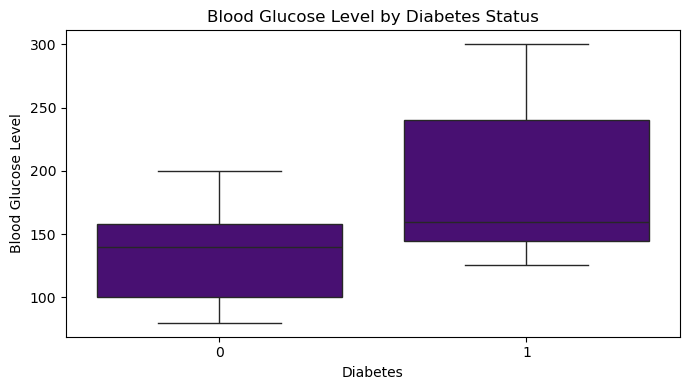

In [23]:
#Blood glucose vs diabetes
plt.figure(figsize=(7, 4))
sns.boxplot(data=df,x="diabetes", y="blood_glucose_level",color='indigo')
plt.title("Blood Glucose Level by Diabetes Status")
plt.xlabel("Diabetes")
plt.ylabel("Blood Glucose Level")
plt.tight_layout()
plt.show()

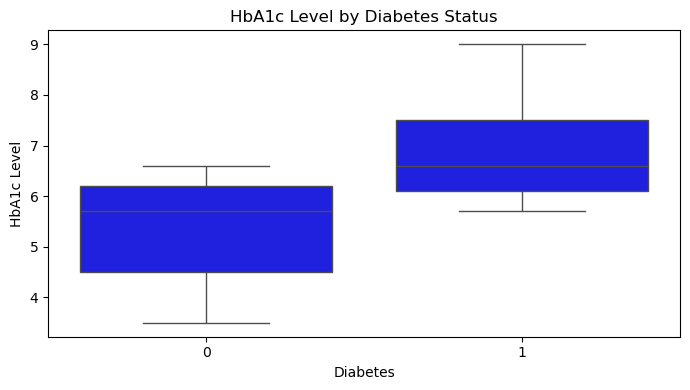

In [25]:
#HbA1c vs diabetes
plt.figure(figsize=(7, 4))
sns.boxplot(data=df,x="diabetes",y="HbA1c_level",color='blue')
plt.title("HbA1c Level by Diabetes Status")
plt.xlabel("Diabetes")
plt.ylabel("HbA1c Level")
plt.tight_layout()
plt.show()

In [27]:
#Separate features and target
x = df.drop("diabetes", axis=1)
y = df["diabetes"]

print("Features shape:", x.shape)
print("Target shape:", y.shape)

Features shape: (1996, 8)
Target shape: (1996,)


In [65]:
#Train-test splitting
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=42,
)
print("Training data:", x_train.shape)
print("Testing data:", x_test.shape)

Training data: (1596, 8)
Testing data: (400, 8)


In [66]:
#Preprocessing method
num_features = ["age","hypertension","heart_disease","bmi","HbA1c_level","blood_glucose_level"]
cat_features = ["gender", "smoking_history"]
prep = ColumnTransformer(transformers=[("numerical",StandardScaler(),num_features),("categorical",OneHotEncoder(handle_unknown="ignore"),cat_features)])

In [67]:
#Building the Logistic Regression model
lr_model = Pipeline(steps=[("preprocessing", prep),("logistic",LogisticRegression(max_iter=1000,random_state=42))])

In [68]:
#model Trian
lr_model.fit(x_train, y_train)
print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [69]:
#predictions
lr_pred = lr_model.predict(x_test)
lr_prob = lr_model.predict_proba(x_test)[:, 1]

print("First 10 predictions:")
print(lr_pred[:10])

First 10 predictions:
[0 0 1 0 0 0 0 0 1 0]


In [80]:
#Calculating the evaluation metrics
lr_accuracy = accuracy_score(y_test, lr_pred)
lr_precision = precision_score(y_test,lr_pred)
lr_recall = recall_score(y_test,lr_pred)
lr_f1 = f1_score(y_test,lr_pred,average="weighted")
lr_auc = roc_auc_score(y_test,lr_prob)

print("Logistic Regression Results")
print("---------------------------")
print("Accuracy    :", lr_accuracy)
print("Precision   :",lr_precision)
print("Recall      :",lr_recall)
print("Weighted F1 :",lr_f1)
print("ROC-AUC     :", lr_auc)

Logistic Regression Results
---------------------------
Accuracy    : 0.945
Precision   : 0.7241379310344828
Recall      : 0.6
Weighted F1 : 0.9426460597826087
ROC-AUC     : 0.952720156555773


In [81]:
#Classification report
print(classification_report(y_test,lr_pred))

              precision    recall  f1-score   support

           0       0.96      0.98      0.97       365
           1       0.72      0.60      0.66        35

    accuracy                           0.94       400
   macro avg       0.84      0.79      0.81       400
weighted avg       0.94      0.94      0.94       400



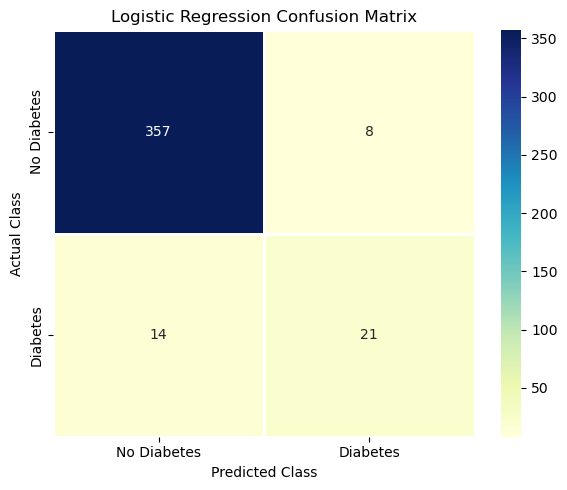

In [72]:
#Confusion matrix Diplay
cm_lr = confusion_matrix(y_test,lr_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_lr,annot=True,fmt="d",cmap="YlGnBu",linewidths=0.8,
    xticklabels=["No Diabetes", "Diabetes"],yticklabels=["No Diabetes", "Diabetes"])
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()
plt.show()

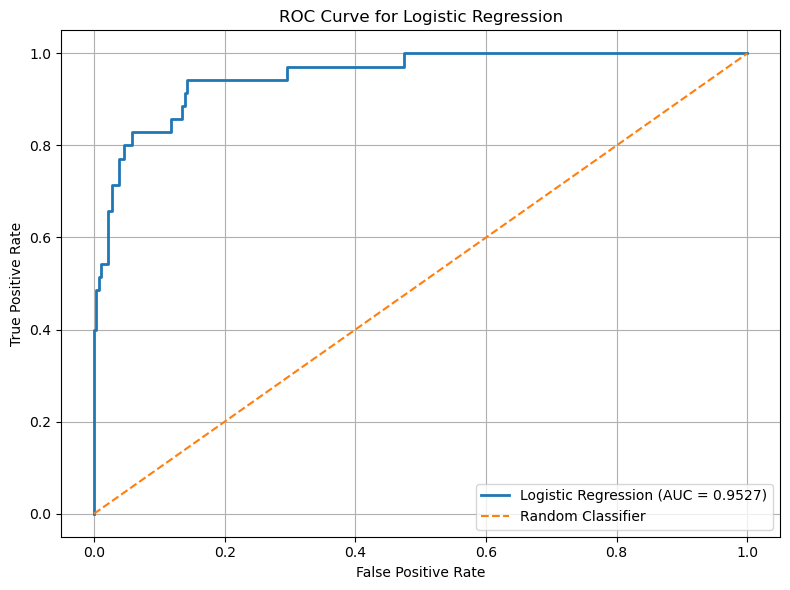

In [84]:
#ROC curve(Area under the curve)
fpr_lr, tpr_lr, thresholds_lr = roc_curve(y_test,lr_prob)
plt.figure(figsize=(8, 6))
plt.plot(fpr_lr,tpr_lr,linewidth=2,label=f"Logistic Regression (AUC = {lr_auc:.4f})")
plt.plot([0, 1],[0, 1],linestyle="--",label="Random Classifier")
plt.title("ROC Curve for Logistic Regression")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

In [74]:
#Logistic Regression result
lr_result = pd.DataFrame({
    "Algorithm Ued": ["Logistic Regression"],
    "Accuracy": [lr_accuracy],
    "Precision core": [lr_precision],
    "Recall": [lr_recall],
    "Weighted F1": [lr_f1],
    "ROC-AUC": [lr_auc]})
lr_result

,Algorithm Ued,Accuracy,Precision core,Recall,Weighted F1,ROC-AUC
0,Logistic Regression,0.945,0.724138,0.6,0.942646,0.95272
